# Plot timeseries of ocean and atm. variables in north Pacific in -6% Solar experiments

* MHT
* $S$
* $T$
* wind
* evap
* precip
* $E-P$
* vertical diffusivity
* $N^2$

Created Aug 11 2025

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4

from solar_func import rename_latlon

plt.style.use('../func/paper.mplstyle')

In [2]:
def load_files(directory, start_str):
    
    import os
    files = [f for f in os.listdir(directory) if f.startswith(start_str)]

    if files:
        if len(files) == 1:
            files = [files[0]]
    else:
        print("No file found.")
    
    filelist = [directory + '/' + filename  for filename in files]

    # open files
    ds = xr.open_mfdataset(filelist,
                       parallel=False,
                       combine='by_coords',use_cftime=True)
    
    variable_names = list(ds.data_vars)
    da = ds[variable_names[0]]
    
    return da
    
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
#              'p6p0sol_CTL1860',
#                 'p4p0sol_CTL1860',
#                 'p2p0sol_CTL1860', 
#                 'p1p0sol_CTL1860',
#                 'm1p0sol_CTL1860', 
#                 'm2p0sol_CTL1860',
#                 'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',]
        modelstr = 'FLOR'
        CTRLname = 'CTL1860_newdiag'

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
#             'CTL1860_p6pctSolar', 
#                 'CTL1860_p4pctSolar',
#                 'CTL1860_p2pctSolar',
#                 'CTL1860_p1pctSolar',
#                 'CTL1860_m1pctSolar',
#                 'CTL1860_m2pctSolar',
#                 'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
        ]
        modelstr = 'CM2.1'
        CTRLname = 'CTL1860'
    return exps, extension, modelstr, CTRLname

In [9]:
def file_exists(filepath):
    import os
    return os.path.isfile(filepath)

In [3]:
def get_domain(da, lat1=40, lat2=60, lon1=-190, lon2=-140, ocean=True):
    # select lon limits
    if ocean == False:
        lon1 = lon1 + 360
        lon2 = lon2 + 360
    da_new = da.sel(lat=slice(lat1,lat2),lon=slice(lon1,lon2))
    
    return da_new

In [4]:
def get_JFM_ts(da):
    # Select JFM months
    jfm = da.sel(time=da['time'].dt.month.isin([1, 2, 3]))
    
    # Compute seasonal (JFM) mean for each year
    jfm_mean = jfm.groupby('time.year').mean('time')

    return jfm_mean

## load Pacific meridional heat transport in both models for CTRL and -6% Solar experiments


In [5]:
lat = 40 # degrees N

FLOR_Pmht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_FLOR_m6p0sol_CTL1860.0101-0597.nc')
CM21_Pmht_m6 = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_CM2.1p1_CTL1860_m6pctSolar.0101-1293.nc')

FLOR_Pmht_CTRL = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_FLOR_CTL1860_newdiag.0101-2100.nc')
CM21_Pmht_CTRL = xr.open_dataarray(f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_CM2.1p1_CTL1860.0101-2100.nc')


In [6]:
CM21_Pmht_m6 = CM21_Pmht_m6.isel(year=slice(0,100))
FLOR_Pmht_m6 = FLOR_Pmht_m6.isel(year=slice(0,100))

CM21_Pmht_CTRL = CM21_Pmht_CTRL.isel(year=slice(0,100))
FLOR_Pmht_CTRL = FLOR_Pmht_CTRL.isel(year=slice(0,100))

## Load $N^2$ data

In [7]:
def preprocess(filein):
    da = xr.open_dataarray(filein)
    da = rename_latlon(da)
    #da = da.sel(depth=slice(0,200)).mean('depth')
    weights = np.cos(np.deg2rad(da.lat))
    da = da.weighted(weights).mean(('lat','lon'))
    #da = da.groupby('time.month').mean('time')
    return da

In [8]:
N2_FLOR_CTRL = preprocess('./processed_data/N2_FLOR_CTRL_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL = preprocess('./processed_data/N2_CM2.1p1_CTRL_0101-0200_NPacific_box1.nc')
N2_FLOR_m6 = preprocess('./processed_data/N2_FLOR_m6_0101-0200_NPacific_box1.nc')
N2_CM21_m6 = preprocess('./processed_data/N2_CM2.1p1_m6_0101-0200_NPacific_box1.nc')

# JFM timeseries with MHT and $N^2$

E-P
E-P


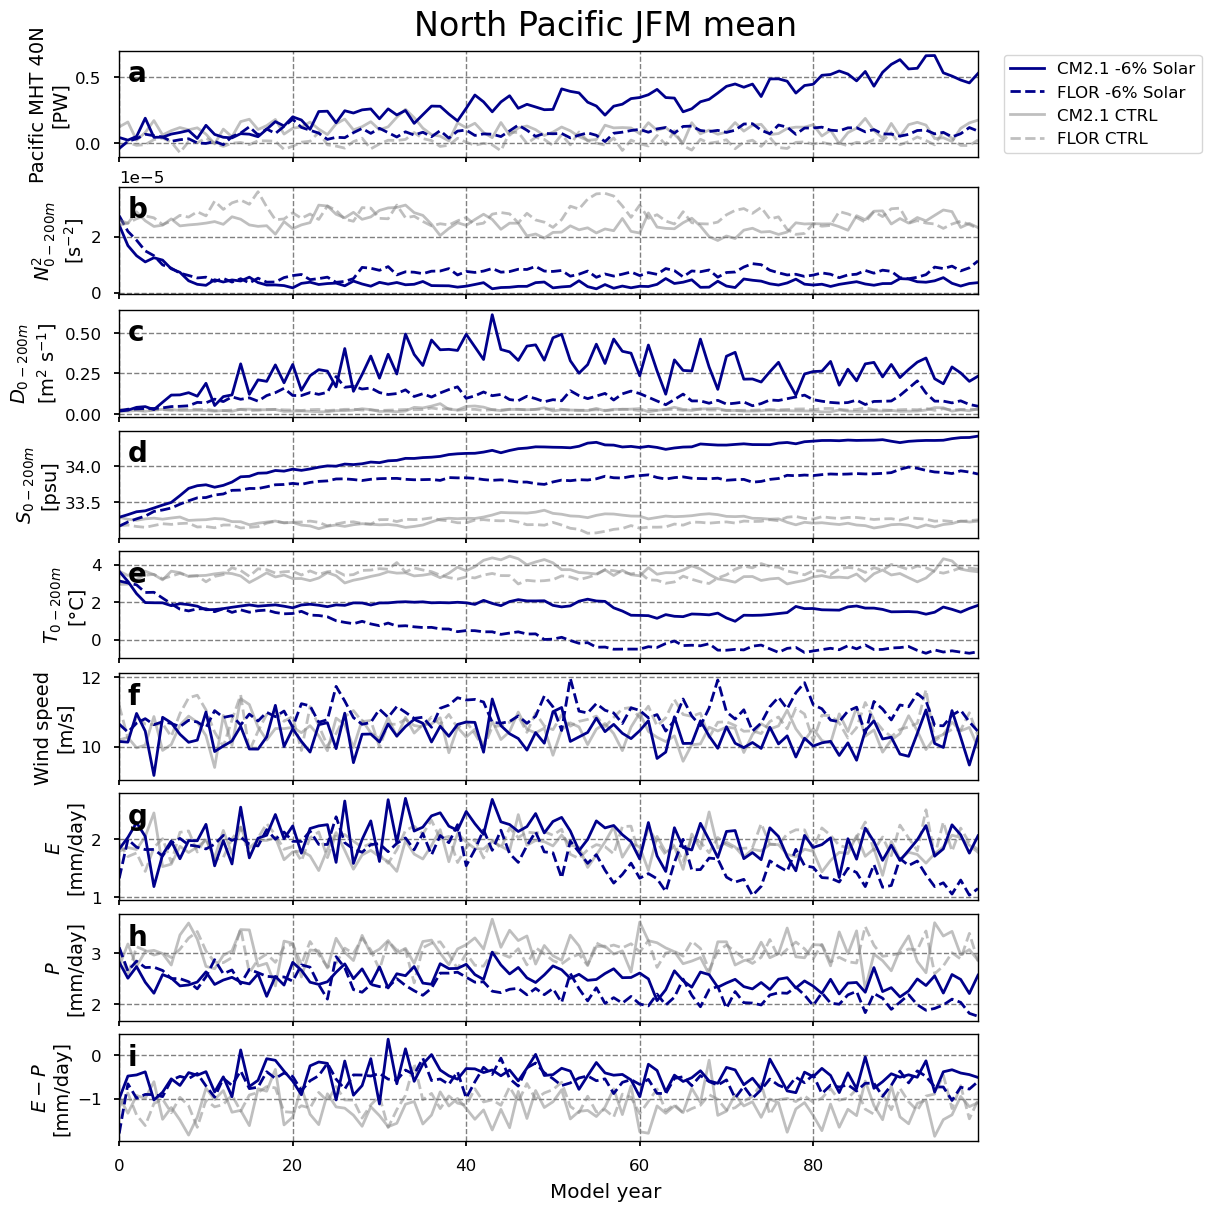

In [13]:
# plot timeseries
# takes a few minutes

vars = 'diff_cbt_t salt temp wind evap precip E-P'
varnames = vars.split()

modelnames = ['CM2.1p1','FLOR']
modelcolors = ['darkblue','darkblue']
model_linestyles = ['-','--']

fig, ax = plt.subplots(np.size(varnames)+2, 1, figsize=(12,12), sharex=True)

time = np.arange(0,100,1)

### plot the MHT ###
ax[0].plot(time, 
           (CM21_Pmht_m6*1e-15),
           color='darkblue',linestyle='-',label='CM2.1 -6% Solar',zorder=1)
ax[0].plot(time,
           (FLOR_Pmht_m6*1e-15),color='darkblue',linestyle='--',label='FLOR -6% Solar',zorder=1)
ax[0].plot(time,
           (CM21_Pmht_CTRL*1e-15)
           ,color='gray',linestyle='-',label='CM2.1 CTRL',zorder=0, alpha=0.5)
ax[0].plot(time,
           (FLOR_Pmht_CTRL*1e-15),color='gray',linestyle='--',label='FLOR CTRL',zorder=0, alpha=0.5)
ax[0].set_ylabel('Pacific MHT 40N\n[PW]')

### plot depth-averaged N^2 ###
ax[1].plot(time, get_JFM_ts(N2_CM21_m6).sel(depth=slice(0,200)).mean('depth'),
                                                                  color='darkblue', linestyle='-', 
                                                                  label='CM2.1 -6% Solar', zorder=1)
ax[1].plot(time, get_JFM_ts(N2_FLOR_m6).sel(depth=slice(0,200)).mean('depth'),
                                                                  color='darkblue', linestyle='--', 
                                                                  label='FLOR -6% Solar', zorder=1)
ax[1].plot(time, get_JFM_ts(N2_CM21_CTRL).sel(depth=slice(0,200)).mean('depth'),
                                                                    color='gray', linestyle='-', label='CM2.1 CTRL', alpha=0.5)
ax[1].plot(time, get_JFM_ts(N2_FLOR_CTRL).sel(depth=slice(0,200)).mean('depth'),
                                                                    color='gray', linestyle='--', label='FLOR CTRL', alpha=0.5)
ax[1].set_ylabel('$N^2_{0-200m}$\n[s$^{-2}$]')

##### plot the other variables #####
dir_data_ocean = './MODEL_OUT/NPacific'
dir_data_atm = './MODEL_OUT/'

dir_data = [dir_data_ocean, dir_data_ocean, dir_data_ocean, dir_data_atm, dir_data_atm, dir_data_atm, dir_data_atm]
isocean = [True, True, True, False, False, False, False]
CTRLcolors = ['gray', 'gray']
ylabels = ['$D_{0-200m}$\n[m$^2$ s$^{-1}$]', '$S_{0-200m}$\n[psu]', '$T_{0-200m}$\n[°C]', 'Wind speed\n[m/s]', '$E$\n[mm/day]', '$P$\n[mm/day]', '$E-P$\n[mm/day]']

for ii in range(np.size(modelnames)):
    
    # get the names of the experiments
    exps, extension, modelstr, CTRLname = get_experiment_names(modelnames[ii])
    
    for ivar in range(len(varnames)):
    
        for iexp in range(np.size(exps)):

            ofile = f'./processed_data/{varnames[ivar]}_{modelnames[ii]}_{exps[iexp]}_JFM_NPacific_box_0101-0200.nc'
            ofile_CTRL = f'./processed_data/{varnames[ivar]}_{modelnames[ii]}_{CTRLname}_JFM_NPacific_box_0101-0200.nc'

            if varnames[ivar] != 'E-P':
                #if file does not exist
                if file_exists(ofile) == True:
                    da_ts = xr.open_dataarray(ofile)
                else:
                    # load experiment data
                    filein = f'{varnames[ivar]}_{modelnames[ii]}_{exps[iexp]}_{extension}'
                    print(filein)
                    da = load_files(dir_data[ivar],filein)
            else:
                # load P-E data
                print('E-P')
                da_evap = load_files(dir_data[ivar],f'evap_{modelnames[ii]}_{exps[iexp]}_{extension}')
                da_precip = load_files(dir_data[ivar],f'precip_{modelnames[ii]}_{exps[iexp]}_{extension}')
                da = da_evap - da_precip # E-P at every time and space point

            if file_exists(ofile) == False:
                da = rename_latlon(da)
                
                if isocean[ivar] == True:
                    da = da.sel(depth=slice(0,200)).mean('depth')
                
                # get experiment timeseries in box
                da_ts = get_domain(da.isel(time=slice(0,12*100)), 
                                    ocean=isocean[ivar]).mean(('lat','lon'))#.groupby('time.year').mean('time')
                da_ts = get_JFM_ts(da_ts)
            
            ax[ivar+2].plot(time,
                            da_ts,
                            label=f'{modelstr} -6% Solar', linestyle = model_linestyles[ii], color=modelcolors[ii], zorder=1)
        
        # load Control
        if varnames[ivar] != 'E-P':
            if file_exists(ofile_CTRL) == True:
                CTRL_ts = xr.open_dataarray(ofile_CTRL)
            else:
                CTRL = load_files(dir_data[ivar],f'{varnames[ivar]}_{modelnames[ii]}_{CTRLname}_{extension}')
        else:
            CTRL_evap = load_files(dir_data[ivar],f'evap_{modelnames[ii]}_{CTRLname}_{extension}')
            CTRL_precip = load_files(dir_data[ivar],f'precip_{modelnames[ii]}_{CTRLname}_{extension}')
            CTRL = CTRL_evap - CTRL_precip # E-P at every time and space point

        if file_exists(ofile_CTRL) == False:
            CTRL = rename_latlon(CTRL)
            
            if isocean[ivar] == True:
                CTRL = CTRL.sel(depth=slice(0,200)).mean('depth')
            
            # get CTRL timeseries in box
            CTRL_ts = get_domain(CTRL.isel(time=slice(0,12*100)), 
                                    ocean=isocean[ivar]).mean(('lat','lon'))#.groupby('time.year').mean('time')
            CTRL_ts = get_JFM_ts(CTRL_ts)    
        
        ax[ivar+2].plot(time,
                        CTRL_ts,
                        label=f'{modelstr} CTRL', color=CTRLcolors[ii], linestyle=model_linestyles[ii], zorder=0, alpha=0.5)

        ax[ivar+2].set_ylabel(ylabels[ivar])

        # save data
        if varnames[ivar] != 'E-P':
            if file_exists(ofile) == False:
                da_ts.to_netcdf(ofile)
            if file_exists(ofile_CTRL) == False:
                CTRL_ts.to_netcdf(ofile_CTRL)
        
for axis in ax:
    axis.set_xlabel('')
    axis.grid('--')
    axis.set_xlim(0,99)

ax[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.supxlabel('Model year')
fig.suptitle('North Pacific JFM mean')

# add subplot labels
import string
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
for i, axis in enumerate(ax):
    axis.text(
        0.01, 0.92, f'{letters[i]}', 
        transform=axis.transAxes, 
        fontsize=20, fontweight='bold',
        va='top', ha='left'
    )

plt.savefig('FigureS11.pdf', bbox_inches='tight', dpi=200)